In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Books_Data_Clean.csv')

In [5]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [6]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [8]:
df = df[df['Publishing Year'] > 1900]

In [9]:
df.isna().sum()

index                   0
Publishing Year         0
Book Name              21
Author                  0
language_code          49
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [10]:
df.dropna(subset="Book Name",inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

index                  988
Publishing Year        101
Book Name              987
Author                 669
language_code            8
Author_Rating            4
Book_average_rating    133
Book_ratings_count     983
genre                    4
gross sales            774
publisher revenue      570
sale price             143
sales rank             818
Publisher                9
units sold             470
dtype: int64

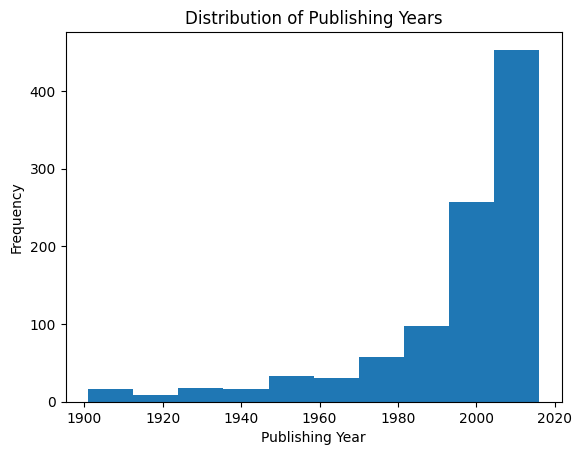

In [13]:
plt.hist(df["Publishing Year"])
plt.xlabel("Publishing Year")
plt.ylabel("Frequency")
plt.title("Distribution of Publishing Years")
plt.show()


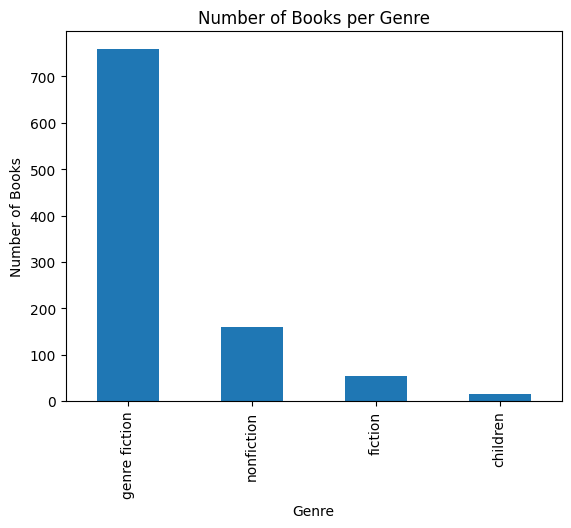

In [14]:
df["genre"].value_counts().plot(kind='bar')
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.title("Number of Books per Genre")
plt.show()

In [ ]:
# Top 10 best-selling books by units sold
print("Top 10 Best-Selling Books by Units Sold:")
top_units = df.nlargest(10, 'units sold')[['Book Name', 'Author', 'units sold', 'gross sales']]
print(top_units.to_string(index=False))
print("\n" + "="*50 + "\n")
print("Top 10 Best-Selling Books by Gross Sales:")
top_gross = df.nlargest(10, 'gross sales')[['Book Name', 'Author', 'gross sales', 'units sold']]
print(top_gross.to_string(index=False))

Top 10 Best-Selling Books by Units Sold:
                                         Book Name           Author  units sold  gross sales
New Moon: The Complete Illustrated Movie Companion   Mark Cotta Vaz       61560      1560.58
                                     Maybe Someday   Colleen Hoover       61128       969.86
                                          Mr Maybe       Jane Green       61128       562.59
                                Anne of the Island  L.M. Montgomery       60696       139.59
                                     A Stolen Life    Jaycee Dugard       57240       558.60
                           The Immortals of Meluha   Amish Tripathi       56808       418.60
                                    The Lost World Michael Crichton       55728      1398.60
                                           Requiem    Lauren Oliver       55080       698.60
                                 A Crown of Swords    Robert Jordan       54000       137.61
Blood Meridian: Or the Evenin

In [16]:
# Publishers with the highest total revenue
print("Top Publishers by Total Publisher Revenue:")
publisher_revenue = df.groupby('Publisher ')['publisher revenue'].sum().sort_values(ascending=False).head(10)
print(publisher_revenue.to_string())

Top Publishers by Total Publisher Revenue:
Publisher 
Penguin Group (USA) LLC                 191581.104
Random House LLC                        174956.244
Amazon Digital Services,  Inc.          141767.772
HarperCollins Publishers                121769.814
Hachette Book Group                     107410.968
Simon and Schuster Digital Sales Inc     46858.206
Macmillan                                31249.830
HarperCollins Publishing                  2830.806
HarperCollins Christian Publishing        2135.670


In [17]:
# Average sale price per genre
print("Average Sale Price per Genre:")
avg_price_genre = df.groupby('genre')['sale price'].mean().sort_values(ascending=False)
print(avg_price_genre.to_string())

print("\n" + "="*50 + "\n")

print("Average Sale Price per Publisher (Top 10):")
avg_price_publisher = df.groupby('Publisher ')['sale price'].mean().sort_values(ascending=False).head(10)
print(avg_price_publisher.to_string())

Average Sale Price per Genre:
genre
children         6.126667
fiction          5.430926
nonfiction       5.418563
genre fiction    4.617760


Average Sale Price per Publisher (Top 10):
Publisher 
Penguin Group (USA) LLC                 8.758710
Random House LLC                        7.323628
Hachette Book Group                     6.205179
HarperCollins Publishers                6.151587
Simon and Schuster Digital Sales Inc    5.943818
HarperCollins Publishing                5.700000
Macmillan                               5.400769
HarperCollins Christian Publishing      5.240000
Amazon Digital Services,  Inc.          3.205971


Distribution of Books by Language Code:
language_code
eng      670
en-US    226
en-GB     29
en-CA      7
fre        4
spa        2
ara        2
nl         1




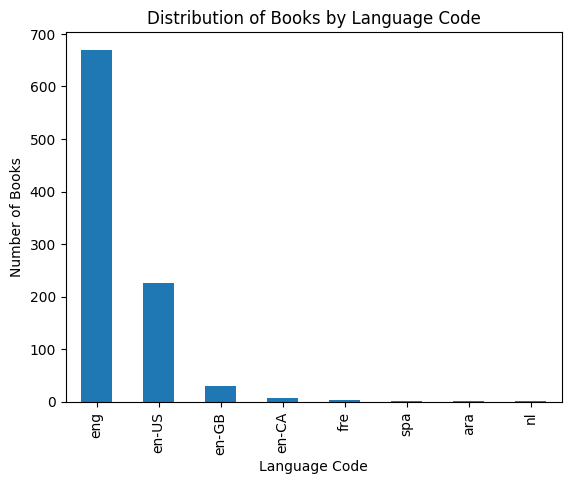

In [18]:
# Distribution of books by language code
print("Distribution of Books by Language Code:")
lang_dist = df['language_code'].value_counts()
print(lang_dist.to_string())

print("\n" + "="*50 + "\n")

# Plot the distribution
lang_dist.plot(kind='bar')
plt.xlabel("Language Code")
plt.ylabel("Number of Books")
plt.title("Distribution of Books by Language Code")
plt.show()